Question: Sandy likes to eat waffles for breakfast. To make them, she centers a circle of waffle batter of radius 3 cm at the origin of the coordinate plane and her waffle iron imprints non-overlapping unit-square holes centered at each lattice point. How many of these holes are contained entirely within the area of the waffle?
To determine how many unit-square holes are contained entirely within the area of the waffle, we need to consider the radius of the waffle circle and the positions of the unit squares. The waffle circle has a radius of 3 cm, so it extends from \(-3\) to \(3\) along both the x-axis and the y-axis. A unit-square hole centered at a lattice point \((x, y)\) will be entirely within the circle if the distance from the center of the circle to the center of the unit square is less than or equal to 2.5 cm. This is because the unit square has a side length of 1 cm, and the distance from the center of the unit square to its edge is 0.5 cm. Thus, the maximum distance from t

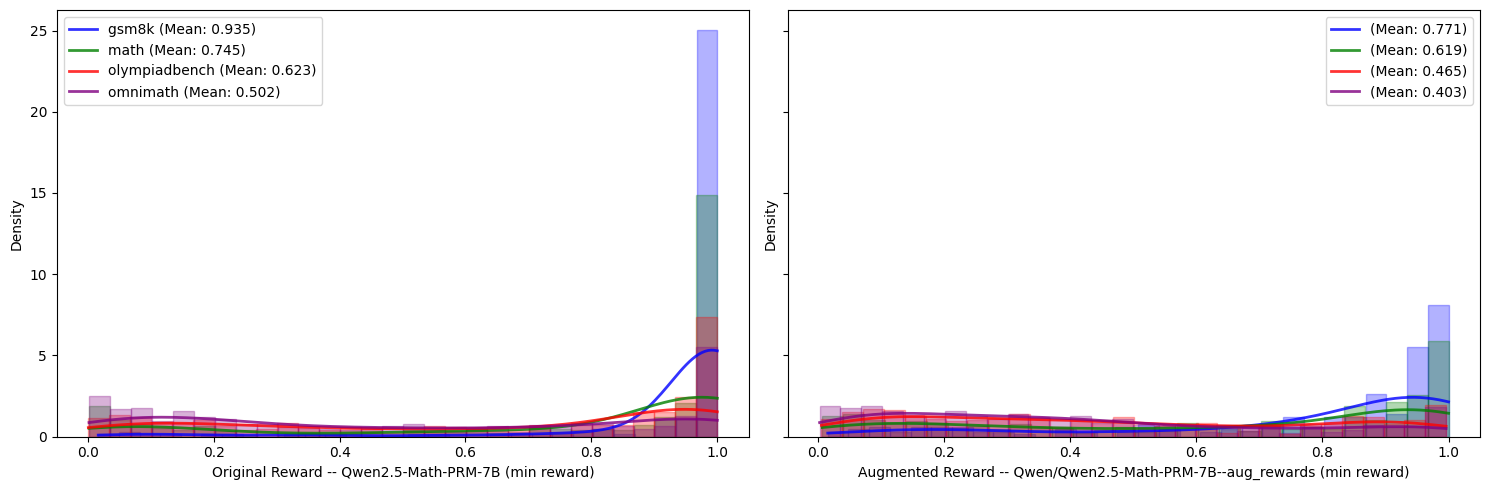

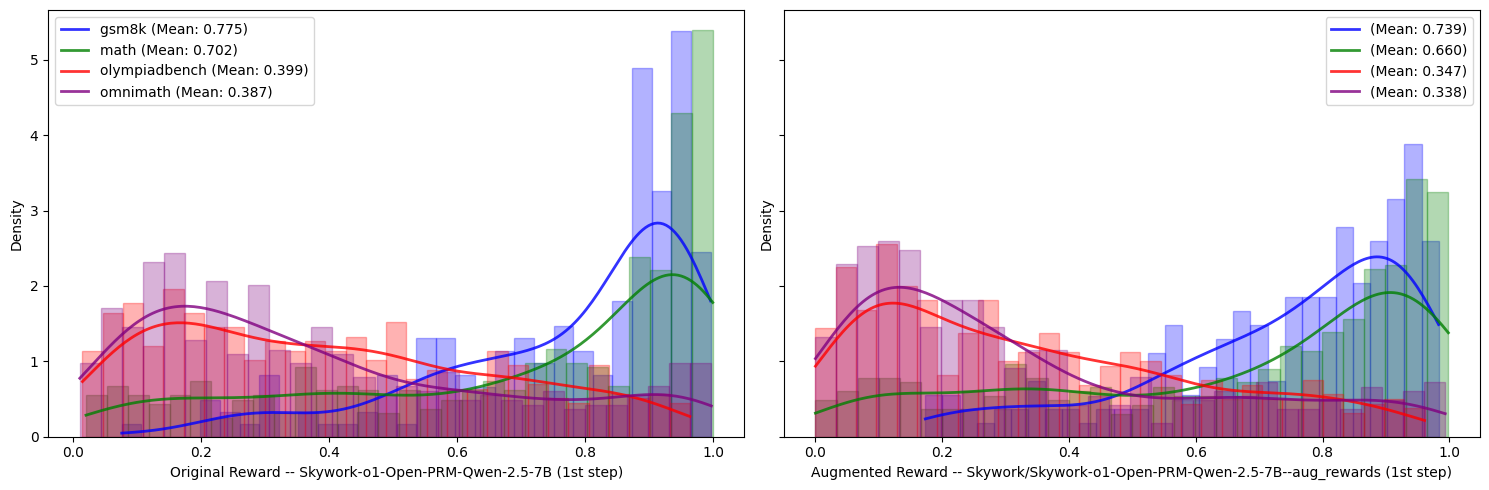

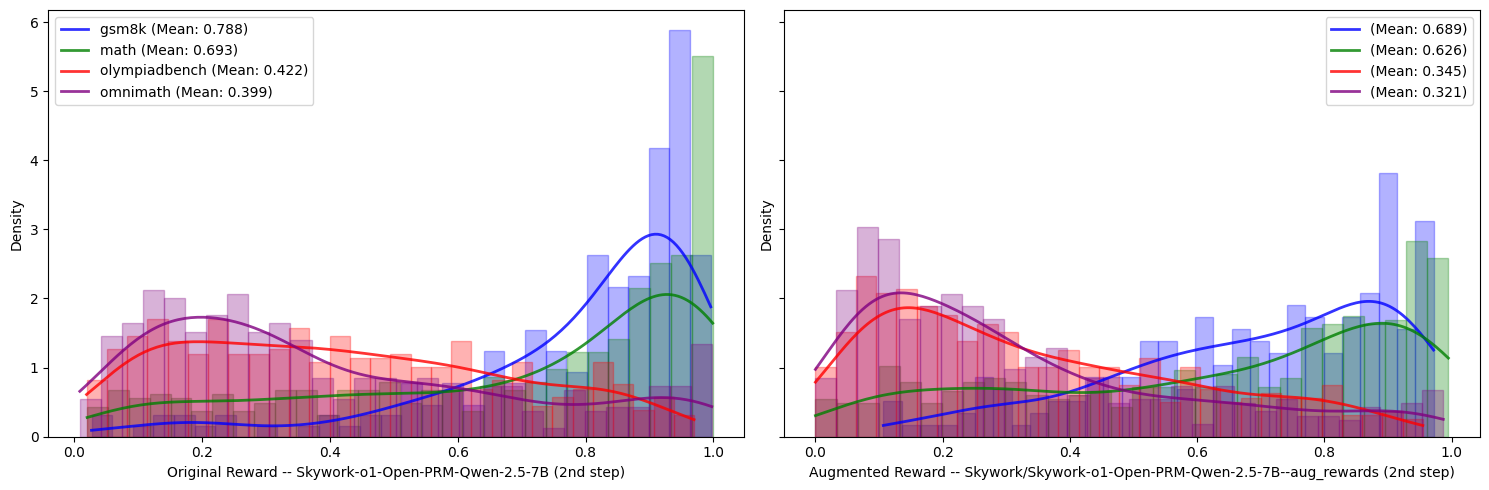

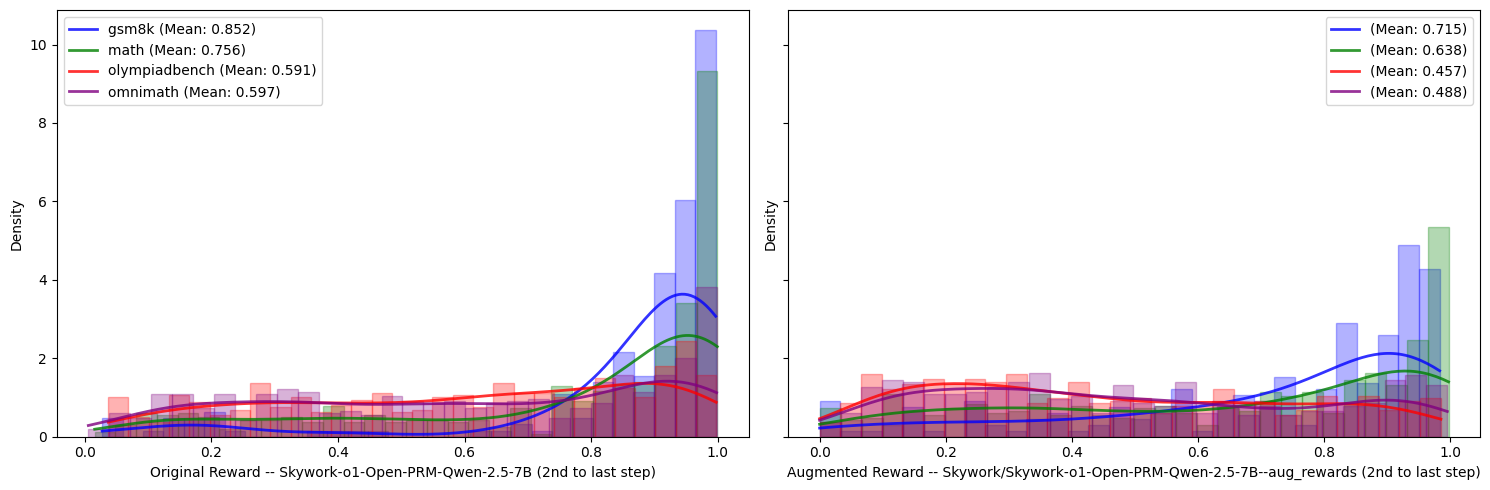

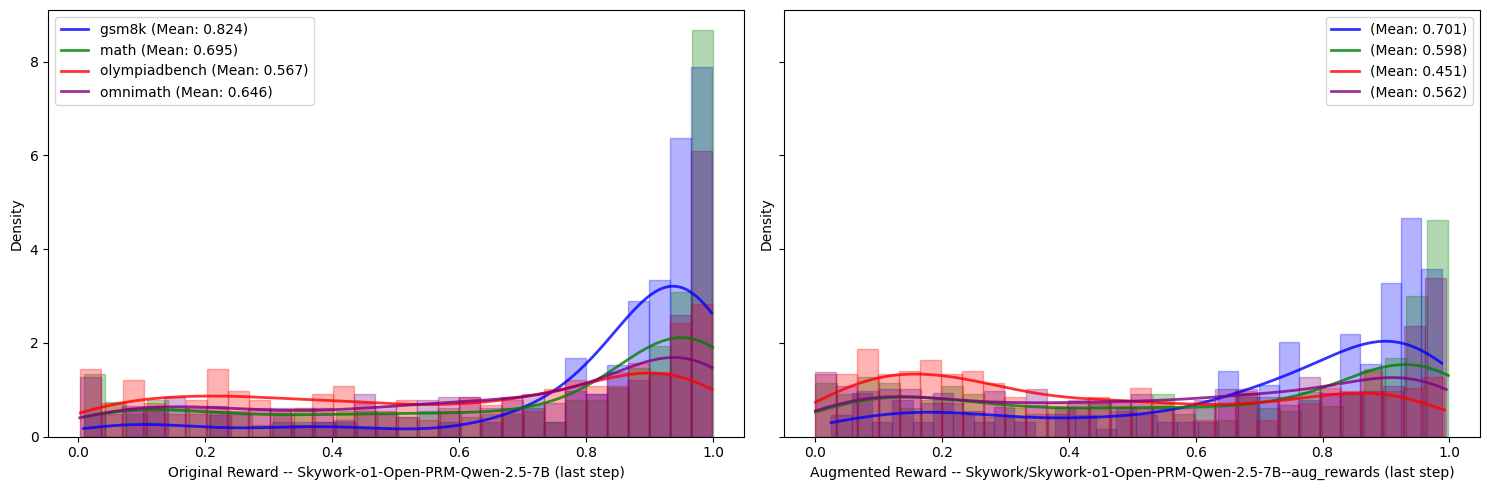

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import random

def to_ordinal(n):
    if n == -1:
        return "last"
    elif n == -2:
        return "2nd to last"
    elif n == 0:
        return "1st"
    elif n == 1:
        return "2nd"

colors = ['blue', 'green', 'red', 'purple']
df = pd.read_parquet(f"attack.parquet")
# select a random question-answer pair from df
question_answer_pair = df.sample(n=1)


print("Question: "+question_answer_pair["problem"].item())
for step in question_answer_pair["steps"].item():
        print(step + "\n")



print("Question: "+question_answer_pair["aug_problem"].item())
for step in question_answer_pair["aug_steps"].item():
        print(step + "\n")
print("#############################################")

print(question_answer_pair["Qwen2.5-Math-PRM-7B"].item())
print(question_answer_pair["Skywork-o1-Open-PRM-Qwen-2.5-7B"].item())

model = ["Qwen2.5-Math-PRM-7B", "Qwen/Qwen2.5-Math-PRM-7B--aug_rewards"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for i, dataset in enumerate(["gsm8k", "math", "olympiadbench", "omnimath"]):
        df_sample = df[df["split"] == dataset]
        df_sample = df_sample[df_sample["final_answer_correct"] == True]

        original_rewards = df_sample[model[0]].apply(lambda x: min(x)).to_numpy()
        augmented_rewards = df_sample[model[1]].apply(lambda x: min(x)).to_numpy()

        # Original plot
        ax1.hist(original_rewards, bins=30, density=True, alpha=0.3,
                edgecolor=colors[i], color=colors[i])
        kde = stats.gaussian_kde(original_rewards)
        # Determine x_range based on the data for this subplot
        x_range_orig = np.linspace(original_rewards.min(), original_rewards.max(), 200)
        ax1.plot(x_range_orig, kde(x_range_orig), color=colors[i], lw=2, alpha=0.8,
                label=f'{dataset} (Mean: {original_rewards.mean():.3f})')

        # Augmented plot
        ax2.hist(augmented_rewards, bins=30, density=True, alpha=0.3,
                edgecolor=colors[i], color=colors[i])
        kde = stats.gaussian_kde(augmented_rewards)
        # Determine x_range based on the data for this subplot
        x_range_aug = np.linspace(augmented_rewards.min(), augmented_rewards.max(), 200)
        ax2.plot(x_range_aug, kde(x_range_aug), color=colors[i], lw=2, alpha=0.8,
                label=f'(Mean: {augmented_rewards.mean():.3f})')


ax1.set_xlabel(f'Original Reward -- {model[0]} (min reward)')
ax1.set_ylabel('Density')
ax1.legend()

ax2.set_xlabel(f'Augmented Reward -- {model[1]} (min reward)')
ax2.set_ylabel('Density') # Y-label is the same as ax1 due to shared y-axis, but can be set explicitly if needed for clarity
ax2.legend()

plt.tight_layout()
plt.show()

model = ["Skywork-o1-Open-PRM-Qwen-2.5-7B", "Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"]
for step_num in [0, 1, -2, -1]:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

        for i, dataset in enumerate(["gsm8k", "math", "olympiadbench", "omnimath"]):
        #for i in range(1):
                df_sample = df[df["split"] == dataset]
        #     df_sample = df
                df_sample = df_sample[df_sample["final_answer_correct"] == True]
                original_rewards = df_sample[model[0]].apply(lambda x: x[step_num]).to_numpy()
                augmented_rewards = df_sample[model[1]].apply(lambda x: x[step_num] if len(x)>abs(step_num) else 0).to_numpy()

                # Original plot
                ax1.hist(original_rewards, bins=30, density=True, alpha=0.3,
                        edgecolor=colors[i], color=colors[i])
                kde = stats.gaussian_kde(original_rewards)
                # Determine x_range based on the data for this subplot
                x_range_orig = np.linspace(original_rewards.min(), original_rewards.max(), 200)
                ax1.plot(x_range_orig, kde(x_range_orig), color=colors[i], lw=2, alpha=0.8,
                        label=f'{dataset} (Mean: {original_rewards.mean():.3f})')

                # Augmented plot
                ax2.hist(augmented_rewards, bins=30, density=True, alpha=0.3,
                        edgecolor=colors[i], color=colors[i])
                kde = stats.gaussian_kde(augmented_rewards)
                # Determine x_range based on the data for this subplot
                x_range_aug = np.linspace(augmented_rewards.min(), augmented_rewards.max(), 200)
                ax2.plot(x_range_aug, kde(x_range_aug), color=colors[i], lw=2, alpha=0.8,
                        label=f'(Mean: {augmented_rewards.mean():.3f})')


        ax1.set_xlabel(f'Original Reward -- {model[0]} ({to_ordinal(step_num)} step)')
        ax1.set_ylabel('Density')
        ax1.legend()

        ax2.set_xlabel(f'Augmented Reward -- {model[1]} ({to_ordinal(step_num)} step)')
        ax2.set_ylabel('Density') # Y-label is the same as ax1 due to shared y-axis, but can be set explicitly if needed for clarity
        ax2.legend()

        plt.tight_layout()
        plt.show()